In [101]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [102]:
id_list = [925, 165, 9, 477, 291, 162]

In [103]:
nr_of_seeds = 30 #nr of seeds in the experiments
index = 162

In [104]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [105]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse']]
    return topk_d, topk_df

In [106]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_43856\3805261461.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_43856\3805261461.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'


<Axes: xlabel='method', ylabel='rmse'>

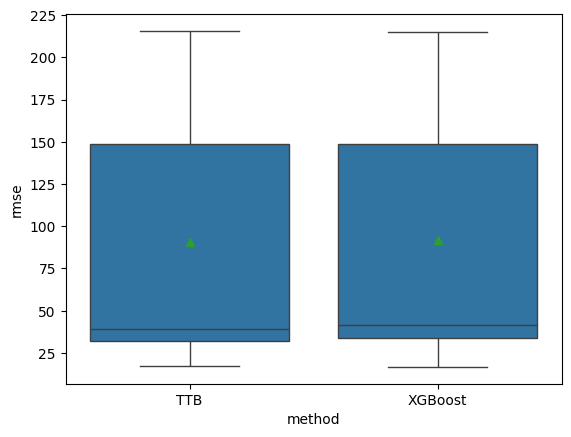

In [107]:


dat = pd.read_csv(f'results/ttb_LS_{index}.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_params_for_us = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results/xgb_{index}.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, lk = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

# data = pd.read_csv(f'results/two_trada_{index}.csv')
# trada_data = data
# trada_data['method'] = 'two-stage TrAdaBoost.R2'

# best_trada, jk = topk_per_d_per_method(
#     trada_data,
# ['method'], k=nr_of_seeds
# )
# best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
#df = best_XGBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
#df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [108]:
best_params_for_us

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
11,0.1,1.0,1.0,0.01,0.5,90.617266,30,860.0,400.0,37.496544,21.210269,213.498046,65.424692,TransferTreeBoost
1276,0.1,1.0,1.0,0.01,0.5,90.617266,30,877.0,400.0,258.161984,83.501251,37.678859,16.176527,TransferTreeBoost
2071,0.1,1.0,1.0,0.01,0.5,90.617266,30,888.0,400.0,211.757915,62.560599,25.761980,21.615909,TransferTreeBoost
859,0.1,1.0,1.0,0.01,0.5,90.617266,30,871.0,400.0,20.060477,15.452065,214.775403,61.853534,TransferTreeBoost
724,0.1,1.0,1.0,0.01,0.5,90.617266,30,870.0,400.0,215.146305,69.171744,17.377391,16.025831,TransferTreeBoost
1516,0.1,1.0,1.0,0.01,0.5,90.617266,30,881.0,400.0,40.524795,26.692079,143.901153,48.814589,TransferTreeBoost
339,0.1,1.0,1.0,0.01,0.5,90.617266,30,864.0,400.0,36.959410,36.370932,37.331660,36.414102,TransferTreeBoost
2011,0.1,1.0,1.0,0.01,0.5,90.617266,30,887.0,400.0,144.892615,53.526790,25.879617,23.101961,TransferTreeBoost
507,0.1,1.0,1.0,0.01,0.5,90.617266,30,867.0,400.0,33.880574,29.965057,31.160102,28.372001,TransferTreeBoost
1155,0.1,1.0,1.0,0.01,0.5,90.617266,30,876.0,400.0,30.394129,28.474285,34.302355,32.147903,TransferTreeBoost


In [109]:
lk

,v,target_tree_size,avg_rmse,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
0,0.1,1.0,91.555538,30,0,860.0,37.747660,21.888238,212.964740,64.969575,XGBoost
6,0.1,1.0,91.555538,30,6,861.0,32.222853,27.956947,41.675629,33.339816,XGBoost
12,0.1,1.0,91.555538,30,12,862.0,37.248102,22.561300,213.190379,61.308924,XGBoost
18,0.1,1.0,91.555538,30,18,863.0,141.571427,51.762164,37.323207,32.247868,XGBoost
24,0.1,1.0,91.555538,30,24,864.0,37.493759,36.135103,39.253905,37.300440,XGBoost
30,0.1,1.0,91.555538,30,30,865.0,18.436001,15.527797,215.090490,68.432267,XGBoost
42,0.1,1.0,91.555538,30,42,867.0,34.903063,30.737991,33.583424,30.055366,XGBoost
36,0.1,1.0,91.555538,30,36,866.0,36.953701,32.437402,40.887238,36.096384,XGBoost
48,0.1,1.0,91.555538,30,48,868.0,144.675772,40.070274,211.973163,52.166989,XGBoost
54,0.1,1.0,91.555538,30,54,869.0,212.897041,67.527904,26.195600,21.050981,XGBoost
